# import library with csv data
import pandas as pd
import numpy as np

!wget https://raw.githubusercontent.com/campusx-official/placement-project-logistic-regression/main/placement.csv

df = pd.read_csv('placement.csv', index_col=0)
df.head()


In [289]:

# read the data
df = pd.read_csv('placement.csv', index_col=0)
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [269]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [270]:
df.shape

(100, 4)

In [271]:
df.size

400

In [272]:
#check information about data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [290]:
#preprocesssing= hume isme pta hai ki pahela column faltu hai to hata denge
df.head()




,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [274]:
#EDA=ye dikhata hai ki data kaisa dikhta hai
#iske lite matplotlib use karte hai
import matplotlib.pyplot as plt


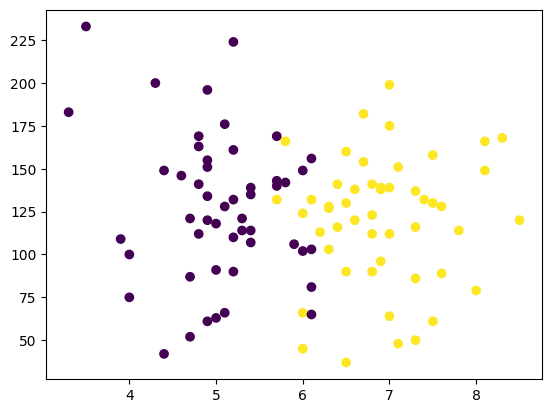

In [275]:
#ye graph banayega  cgpa and iq ka
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])
# comma ke bad vala dekh rha hai ,yellow valo ka placment hua hai baki valo ka nhi



In [276]:
# x= independent varriable
X = df.iloc[:,0:2]
# y= independent varriable
Y = df.iloc[:,-1]
print(X.head())



   cgpa     iq
0   6.8  123.0
1   5.9  106.0
2   5.3  121.0
3   7.4  132.0
4   5.8  142.0


In [277]:
print(Y.head())
Y.shape

0    1
1    0
2    0
3    1
4    0
Name: placement, dtype: int64


(100,)

In [286]:

from sklearn.model_selection import train_test_split

# train test split - 90% train, 10% test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.1, random_state=42)


In [279]:
y_train

,placement
73,0
48,1
10,1
97,1
85,1
...,...
55,1
26,1
93,1
22,0


In [280]:
X_test

,cgpa,iq
70,6.3,127.0
62,6.0,102.0
24,4.7,121.0
78,6.1,81.0
96,4.4,42.0
41,5.4,114.0
57,6.5,130.0
64,7.0,64.0
15,5.1,176.0
32,7.0,139.0


In [281]:
y_test

,placement
70,1
62,0
24,0
78,0
96,0
41,0
57,1
64,1
15,0
32,1


In [291]:

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Sklearn se StandardScaler tool import kiya
scaler = StandardScaler()
# Ek naya blank scaler banaya

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Ek naya blank scaler banaya
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
# X_train ka data normalize kiya (mean=0, std=1)

X_test = scaler.transform(X_test)
# X_test ko sirf transform kiya

model = LogisticRegression()
# Naya blank Logistic Regression model banaya

model.fit(X_train, y_train)
# Model ko train kiya

print(model.score(X_train, y_train))
# Model ki accuracy print kari

0.9444444444444444


In [287]:
y_pred = model.predict(X_test)
print(y_pred)
print(y_test.values)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))


[1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 0 0 0 1 1]
0.7


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


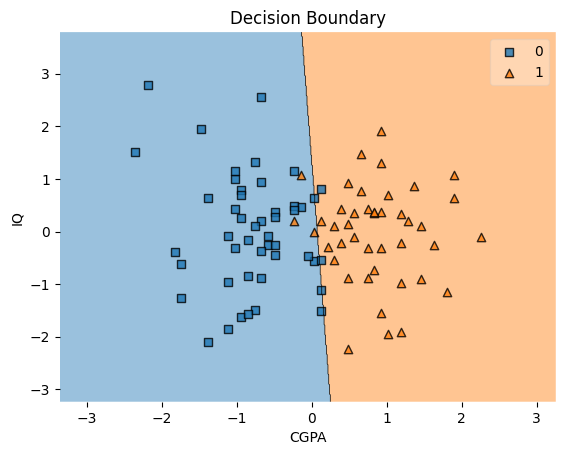

In [292]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
# decision boundary plot
plot_decision_regions(X_train, y_train.values, clf=model)
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('Decision Boundary')
plt.show()




In [293]:
import pickle

In [294]:
pickle.dump(model, open('model.pkl', 'wb'))

In [295]:
# Placement Predictor
import ipywidgets as widgets
from IPython.display import display

cgpa_input = widgets.FloatText(value=7.0, description='CGPA:')
iq_input = widgets.FloatText(value=120.0, description='IQ:')
button = widgets.Button(description='Predict!', button_style='success')
output = widgets.Output()

def predict(b):
    with output:
        output.clear_output()
        inp = scaler.transform([[cgpa_input.value, iq_input.value]])
        result = model.predict(inp)
        prob = model.predict_proba(inp)[0][1] * 100
        if result[0] == 1:
            print(f"✅ PLACED! ({prob:.1f}% chance)")
        else:
            print(f"❌ Not Placed! ({prob:.1f}% chance)")

button.on_click(predict)
display(cgpa_input, iq_input, button, output)

FloatText(value=7.0, description='CGPA:')

FloatText(value=120.0, description='IQ:')

Button(button_style='success', description='Predict!', style=ButtonStyle())

Output()